In [39]:
import pandas as pd
import matplotlib as plt
import seaborn as sns


In [33]:
#lendo o banco
df = pd.read_csv('conflitos.csv')

In [3]:
#quais são as colunas do banco?
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2752 entries, 0 to 2751
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   conflict_id           2752 non-null   int64  
 1   location              2752 non-null   object 
 2   side_a                2752 non-null   object 
 3   side_a_id             2752 non-null   object 
 4   side_a_2nd            455 non-null    object 
 5   side_b                2752 non-null   object 
 6   side_b_id             2752 non-null   object 
 7   side_b_2nd            143 non-null    object 
 8   incompatibility       2752 non-null   int64  
 9   territory_name        1551 non-null   object 
 10  year                  2752 non-null   int64  
 11  intensity_level       2752 non-null   int64  
 12  cumulative_intensity  2752 non-null   int64  
 13  type_of_conflict      2752 non-null   int64  
 14  start_date            2752 non-null   object 
 15  start_prec           

In [40]:
#Substituindo os graus de incompatibilidade pelo que significam
df['incompatibility'] = df['incompatibility'].replace(1, 'territory')
df['incompatibility'] = df['incompatibility'].replace(2, 'government')
df['incompatibility'] = df['incompatibility'].replace(3, 'government and territory')

In [41]:
#Substituindo os graus de tipo de conflito pelo que significam
df['type_of_conflict'] = df['type_of_conflict'].replace(1, 'extrasystemic')
df['type_of_conflict'] = df['type_of_conflict'].replace(2, 'interstate')
df['type_of_conflict'] = df['type_of_conflict'].replace(3, 'intrastate')
df['type_of_conflict'] = df['type_of_conflict'].replace(4, 'internationalized intrastate')

In [42]:
#Substituindo os graus de intensidade de conflito pelo que significam
df['intensity_level'] = df['intensity_level'].replace(1, 'minor')
df['intensity_level'] = df['intensity_level'].replace(2, 'war')

In [43]:
#qual é o motivo mais comum de guerra no mundo?
territorio = df[df['incompatibility'] == 'territory']['incompatibility'].count()
governo = df[df['incompatibility'] == 'government']['incompatibility'].count()
ambos = df[df['incompatibility'] == 'government and territory']['incompatibility'].count()
print(f'conflitos por territorio: {territorio}')
print(f'conflitos por governo: {governo}')
print(f'conflitos por ambos: {ambos}')

conflitos por territorio: 1524
conflitos por governo: 1201
conflitos por ambos: 27


array([<Axes: ylabel='count'>], dtype=object)

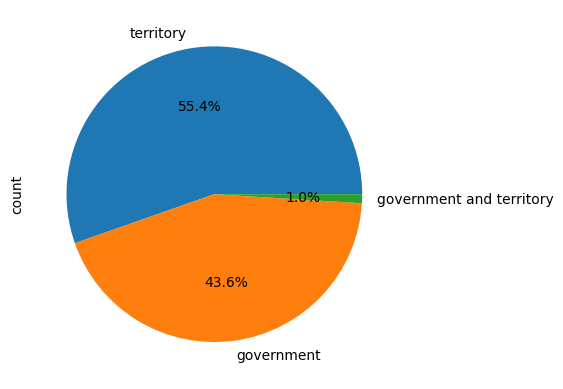

In [8]:
incompatibilidade = df['incompatibility'].value_counts()
incompatibilidade.plot(kind= 'pie', subplots=True, autopct='%1.1f%%')

In [9]:
#qual é o ano mais recente?

ano = df['year'].max()
print(ano)

2024


In [56]:
#nos ultimos 15 anos, o mundo está mais pacifico?
guerras_recentes = df[(df['year'] > 2010) & (df['intensity_level'] == 'war')]
print("guerras dos ultimos anos")
tabela = guerras_recentes.groupby('year')['conflict_id'].nunique()
tabela_df = tabela.reset_index()
print(tabela_df)

guerras dos ultimos anos
    year  conflict_id
0   2011            7
1   2012            6
2   2013            7
3   2014           13
4   2015           11
5   2016           12
6   2017           10
7   2018            6
8   2019            7
9   2020            8
10  2021            5
11  2022            8
12  2023            9
13  2024           11


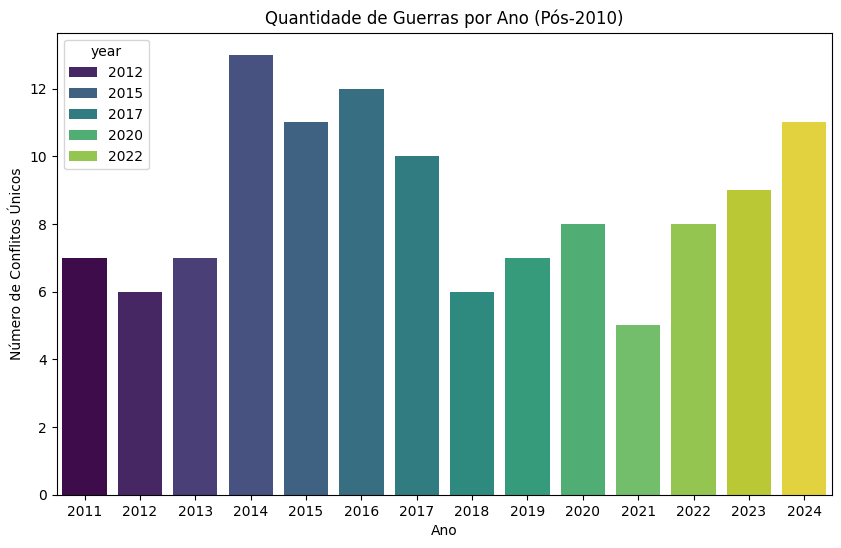

In [61]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.barplot(data=tabela_df, x='year', y='conflict_id', palette='viridis', hue= 'year')
plt.title('Quantidade de Guerras por Ano (Pós-2010)')
plt.xlabel('Ano')
plt.ylabel('Número de Conflitos Únicos')
plt.show()

In [11]:
filtro = df[(df['intensity_level']== 'minor') & (df['cumulative_intensity'] == 1) & (df['year'] == 2024)]
print("Conflitos menores que a guerra e com mais de 1000 mortes em 2024")
filtro.groupby('location')['conflict_id'].nunique().sort_values(ascending= False)

Conflitos menores que a guerra e com mais de 1000 mortes em 2024


location
Myanmar (Burma)             4
Cameroon                    2
DR Congo (Zaire)            2
India                       2
Philippines                 2
Nigeria                     2
Niger                       2
Mali                        2
Afghanistan                 2
Ethiopia                    1
Colombia                    1
Burundi                     1
Central African Republic    1
Burkina Faso                1
Iran, Israel                1
Iraq                        1
Indonesia                   1
Mozambique                  1
Iran                        1
Pakistan                    1
Rwanda                      1
Syria                       1
Thailand                    1
Turkey                      1
Yemen (North Yemen)         1
Name: conflict_id, dtype: int64

In [13]:
#tipo de conflito mais comum
df.groupby('type_of_conflict')['conflict_id'].nunique().sort_values(ascending= False)

type_of_conflict
intrastate                      213
internationalized intrastate     81
interstate                       52
extrasystemic                    21
Name: conflict_id, dtype: int64

In [14]:
#1= extrasystemic (between a state and a non-state 
# group outside its own territory, where the
# government side is fighting to retain control of a
# territory outside the state system)
print("paises mais envolvidos em guerras extrasistemicas: ")
extrasistemica = df[df['type_of_conflict'] == "extrasystemic"]
pais = extrasistemica.groupby('side_a')['conflict_id'].nunique().sort_values(ascending = False)
pais.head()

paises mais envolvidos em guerras extrasistemicas: 


side_a
Government of France            9
Government of United Kingdom    6
Government of Portugal          3
Government of Netherlands       1
Government of Spain             1
Name: conflict_id, dtype: int64

In [15]:
#2= interstate (both sides are states in the Gleditsch
# and Ward membership system).
print("paises mais envolvidos em guerras entre Estados como lado A")
interstate = df[df['type_of_conflict'] == 'interstate']
pais = interstate.groupby('side_a')['conflict_id'].nunique().sort_values(ascending= False)
pais.head(5)

paises mais envolvidos em guerras entre Estados como lado A


side_a
Government of China                   5
Government of Afghanistan             3
Government of Egypt                   3
Government of Chad                    2
Government of Cambodia (Kampuchea)    2
Name: conflict_id, dtype: int64

In [16]:
#ranking por anos de guerra acumulados
paises_guerra = df[df['intensity_level'] == 'war']
top5 = paises_guerra['location'].value_counts()
print("países que mais acumulam anos de guerra:")
top5.head()

países que mais acumulam anos de guerra:


location
Myanmar (Burma)    52
Afghanistan        45
Sudan              38
Ethiopia           35
Angola             25
Name: count, dtype: int64

In [17]:
#conflitos unicos
print("\nRanking por qtd de conflitos distintos:")
ranking_conflitos = paises_guerra.groupby('location')['conflict_id'].nunique().sort_values(ascending=False)
print(ranking_conflitos.head(5))


Ranking por qtd de conflitos distintos:
location
Ethiopia                 6
Indonesia                4
Myanmar (Burma)          4
Russia (Soviet Union)    3
Nigeria                  3
Name: conflict_id, dtype: int64


In [18]:
#no pais top 1 que teve mais guerra, qual foi o motivo principal?
pais = df[(df['intensity_level'] == 'war') & (df['location'] == 'Myanmar (Burma)')]
top1 = pais.groupby('incompatibility')['conflict_id'].nunique().sort_values(ascending= False)
print("No país que teve mais guerra, qual foi a maior incompatibilidade? \n")
print(top1)

No país que teve mais guerra, qual foi a maior incompatibilidade? 

incompatibility
territory     3
government    1
Name: conflict_id, dtype: int64


In [19]:
#vezes em que Israel é mencionado em guerras
israel = df[(df['intensity_level'] == 'war') & (
    (df['side_a'].str.contains('Government of Israel', na=False)) |
    (df['side_b'].str.contains('Government of Israel', na=False)) |
    (df['side_a_2nd'].str.contains('Government of Israel', na=False)) |
    (df['side_b_2nd'].str.contains('Government of Israel', na=False))
    )]
print(f"Israel aparece {israel['conflict_id'].nunique()} vezes como uma das partes de guerras")


Israel aparece 7 vezes como uma das partes de guerras


Total de guerras no banco: 132
Guerras com participação dos EUA: 19
Porcentagem de guerras dos EUA: 14.39%


array([<Axes: >], dtype=object)

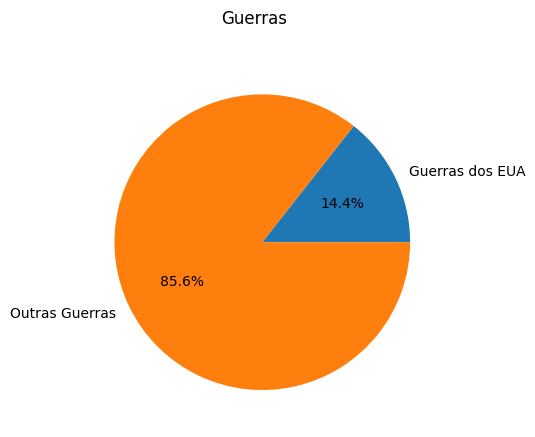

In [20]:
#quantos % de guerra do banco os EUA se envolveram?
total_guerras = df[df['intensity_level']== 'war']['conflict_id'].nunique()
filtro_eua = (df['intensity_level'] == 'war') & (
    (df['side_a'].str.contains('Government of United States', na=False)) | 
    (df['side_b'].str.contains('Government of United States', na=False)) |
    (df['side_a_2nd'].str.contains('Government of United States', na=False)) | 
    (df['side_b_2nd'].str.contains('Government of United States', na=False))
)
guerras_eua = df[filtro_eua]['conflict_id'].nunique()

porcentagem = (guerras_eua / total_guerras)*100
outros = total_guerras - guerras_eua
print(f"Total de guerras no banco: {total_guerras}")
print(f"Guerras com participação dos EUA: {guerras_eua}")
print(f"Porcentagem de guerras dos EUA: {porcentagem:.2f}%")

resumo_pizza = pd.Series([guerras_eua, outros ], index = ['Guerras dos EUA', 'Outras Guerras'])
resumo_pizza.plot.pie(subplots=True, autopct = '%1.1f%%', title = "Guerras")

Guerras de Israel: 6
Outras guerras: 126
Total de guerras: 132


array([<Axes: >], dtype=object)

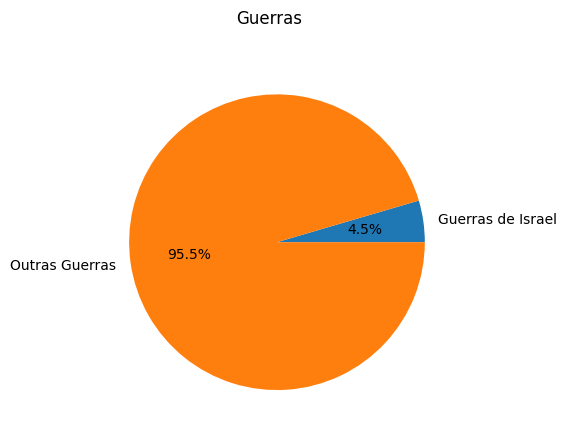

In [22]:
#plotar um grafico da porcentagem de guerras de israel
israel = df[(df['side_a'] == 'Government of Israel') & (df['intensity_level'] == 'war') | (df['side_b'] == 'Government of Israel') & (df['intensity_level'] == 'war')]
guerras_israel = israel['conflict_id'].nunique()
total_guerras = df[df['intensity_level']== 'war']['conflict_id'].nunique()
outras = total_guerras - guerras_israel
print(f'Guerras de Israel: {guerras_israel}')
print(f'Outras guerras: {outras}')
print(f'Total de guerras: {total_guerras}')
resumo_pizza = pd.Series([guerras_israel, outros], index = ['Guerras de Israel', 'Outras Guerras'])
resumo_pizza.plot.pie(subplots=True, autopct = '%1.1f%%', title = "Guerras")


In [24]:
#fazendo recorte
x = df[['incompatibility', 'type_of_conflict', 'intensity_level', 'region']]

In [26]:
import numpy as np
x.replace('Unknown', np.nan, inplace=True)

C:\Users\Cofag\AppData\Local\Temp\ipykernel_15432\1707198912.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x.replace('Unknown', np.nan, inplace=True)


In [27]:
region_dummies = x['region'].str.get_dummies(sep=', ')
x = pd.concat([x.drop('region', axis=1), region_dummies], axis=1)

In [28]:
x.head()

,incompatibility,type_of_conflict,intensity_level,1,2,3,4,5
0,1,3,1,0,0,1,0,0
1,1,3,1,0,0,1,0,0
2,1,2,2,0,1,0,0,0
3,1,2,1,0,1,0,0,0
4,1,2,1,0,1,0,0,0


In [29]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)


In [30]:
from sklearn.neighbors import NearestNeighbors


nbrs = NearestNeighbors(n_neighbors=5, algorithm='auto', metric='euclidean', p=2)
nbrs.fit(x)

neighbor_index = nbrs.kneighbors([x[0]],return_distance=False)
print(neighbor_index)


[[ 1 45 44  0 40]]
